# Comparando diferentes modelos

En esta clase aprenderemos cómo evaluar y comparar diferentes modelos de Machine Learning aplicados a regresión o clasificación.  


---

## ¿Cómo saber qué modelo es el mejor?

Para determinar el **mejor modelo**, se utilizan métricas de evaluación que dependen del tipo de problema:

- 📌 **En problemas de regresión**:
  - **MSE (Error cuadrático medio)** → Penaliza fuertemente los errores grandes.  
  - **RMSE (Raíz del error cuadrático medio)** → Interpretable en las mismas unidades de la variable objetivo.  
  - **MAE (Error absoluto medio)** → Menos sensible a valores atípicos.  
  - **R² (Coeficiente de determinación)** → Mide qué porcentaje de la variabilidad es explicado por el modelo.   

➡️ El "mejor" modelo no siempre es el de mayor precisión, sino el que logra un **equilibrio** entre métricas y se adapta al contexto del problema.

# 1 - IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2 - CARGAMOS DATASET

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep=r'\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# 3 - PREPARACIÓN DE DATOS

In [4]:
corr_matrix = df.corr()
corr_medv = corr_matrix[['MEDV']].sort_values(by='MEDV',ascending=False)
corr_medv

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


In [5]:
cols = corr_medv.index.tolist()
cols.remove('MEDV')
cols

['RM',
 'ZN',
 'B',
 'DIS',
 'CHAS',
 'AGE',
 'RAD',
 'CRIM',
 'NOX',
 'TAX',
 'INDUS',
 'PTRATIO',
 'LSTAT']

In [6]:
X = df[cols].values
y = df['MEDV'].values.reshape(-1,1)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [8]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 2 - ESCALAMIENTO DE DATOS

In [9]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [11]:
results = {}
for name,model in models.items():
    model.fit(X_train_scaled,y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    r2 = r2_score(y_test_scaled,y_pred_scaled)
    mse = mean_squared_error(y_test_scaled,y_pred_scaled)
    mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
    results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS EN UN DATAFRAME

In [12]:
results_df = pd.DataFrame(results).T
results_df

,R2,MSE,MAE
Linear Regression,0.717314,0.331513,0.415150
Lasso,0.677891,0.377746,0.420895
Ridge,0.717535,0.331254,0.414459
KNN Regressor,0.740708,0.304078,0.360961
SVR,0.719447,0.329012,0.379542
Random Forest Regressor,0.898170,0.119419,0.253700


# BUSCAMOS EL MEJOR MODELO

In [13]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8982)
Best model based on MSE: Random Forest Regressor (MSE: 0.12)


# GRAFICAMOS METRICAS DE LOS MODELOS

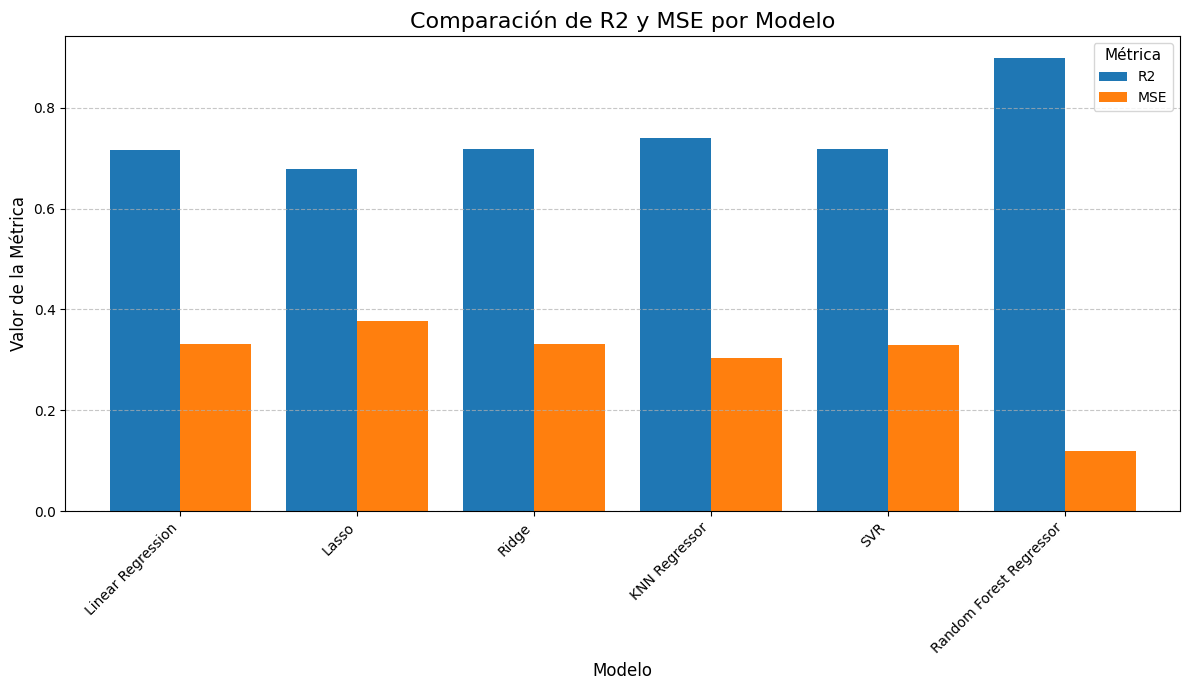

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()